1706
   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0     1615.0     1615.0    3.84644  13.0      4.848032          0.011371   

         r         Q  
0 -0.20204  0.614564  
Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 44/44 [00:00<00:00, 862.87it/s]

--- Power-law Analysis ---
Alpha (Coefficient): 2.3857
xmin (Threshold): 6.0
Loglikelihood Ratio (R): 2.7874
p-value: 0.0053
Result: Power-law is significantly more likely than Exponential.


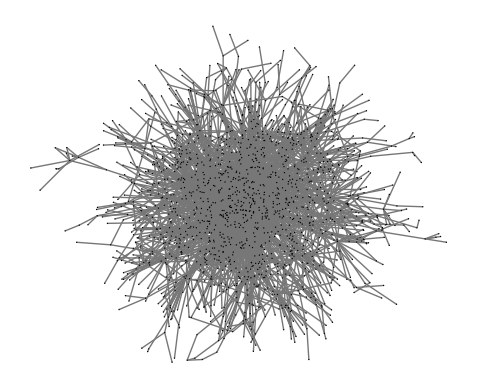

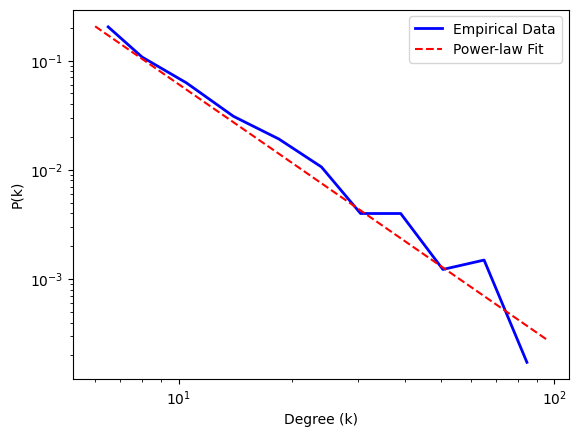

In [24]:
import matplotlib.pyplot as plt
import os
import importlib
import utils
import visualize_dismantling
import baseline
importlib.reload(utils)
importlib.reload(visualize_dismantling)
importlib.reload(baseline)
from utils.common import load_g
from utils.graph_models import statistics
from utils.plot import plot_graph
from utils.structural_diversity_analysis import analyze_powerlaw,statistics

g_name = 'graphs/real/bio/maayan-Stelzl.pkl'

# g_name = 'graphs/real/social/librec-filmtrust-trust.pkl'
# g_name = 'graphs/real/social/petster-hamster.pkl'
# g_name = 'graphs/real/social/librec-ciaodvd-trust.pkl'


# g_name = 'graphs/real/information/dimacs10-polblogs.pkl'
# g_name = 'graphs/real/information/web-EPA.pkl'

# g = load_g(f'graphs/real/FINDER/Crime.pkl',name=g_name)
# g = load_g(f'graphs/real/FINDER/Digg.pkl',name=g_name)
# g = load_g(f'graphs/real/bio/arenas-meta.pkl',name=g_name)
# g = load_g(f'graphs/real/bio/maayan-Stelzl.pkl',name=g_name)
# g = load_g(f'graphs/real/bio/moreno_propro.pkl',name=g_name)
# g = load_g(f'graphs/real/bio/maayan-figeys.pkl',name=g_name)

# g = load_g(f'graphs/real/social/opsahl-ucsocial.pkl',name=g_name)
g = load_g(g_name,name=g_name)


print(g.vcount())


g_lcc = g.connected_components().giant()
plot_graph(g_lcc)
print(statistics(g_lcc))
analyze_powerlaw(g_lcc)

In [21]:
# from utils.common import load_g
# from utils.plot import plot_graph
# import os
# data_dir = "graphs/demo/100_200_LFR_3000"
# for p in os.listdir(data_dir)[100:150]:
#     data_path = os.path.join(data_dir,p)
#     g = load_g(data_path,name=p) 
#     stat = statistics(g)
#     if stat['r'].item() > 0.25:
#         print(g['name'], g['config'])
#         print(stat)
#         plot_graph(g)

### convert txt to pkl

In [ ]:
# import igraph as ig
# import networkx as nx
# import os
# import pickle

# for path in sorted(os.listdir('./real/FINDER')):
#     file_name = os.path.basename(path)
#     print(file_name)
#     g_name = file_name.split('.')[0]
#     g_type = file_name.split('.')[-1]
#     if g_type == 'txt':
#         g = ig.Graph.from_networkx(nx.read_edgelist(path,nodetype=int))
#         with open(f'{g_name}.pkl', 'wb') as out_f:
#             pickle.dump(g, out_f)
    

## Graph models

In [2]:
import igraph as ig
import sys
import utils
import importlib
from utils import graph_models
importlib.reload(graph_models)
importlib.reload(utils)
from utils.plot import plot_graph
from utils.graph_models import statistics
from utils.structural_diversity_analysis import analyze_powerlaw,statistics

#### ER

<AxesSubplot:>

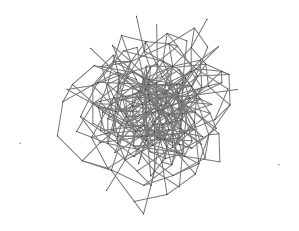

In [2]:
#### BA 
import numpy as np
n = 200
G = ig.Graph.Erdos_Renyi(n, p=np.log(n)/n)
plot_graph(G)

#### BA图

   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      150.0      735.0        9.8   4.0      2.356242          0.155099   

         r         Q  
0 -0.09302  0.273831  
   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      150.0      735.0        9.8   4.0      2.272752          0.234208   

          r         Q  
0 -0.188583  0.250048  
   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      150.0      718.0   9.573333   4.0      2.353557          0.331416   

          r         Q  
0 -0.178381  0.342595  


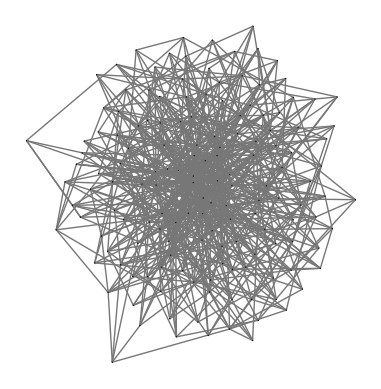

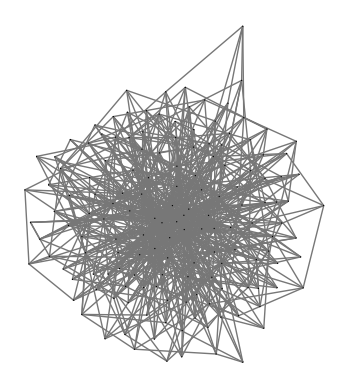

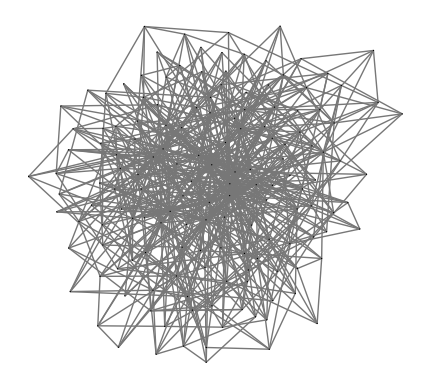

In [49]:
from utils.graph_models import statistics,LPA,holme_kim, powerlaw_cluster
n = 150
m = 5

#### BA 
G = ig.Graph.Barabasi(n, m, directed=False)
plot_graph(G)
print(statistics(G))

G = LPA(n, m, gamma=2.5)
plot_graph(G)
print(statistics(G))

G = powerlaw_cluster(n, m, p=0.6)
plot_graph(G)
print(statistics(G))


   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      500.0     1494.0      5.976   6.0      3.372104          0.037716   

        r         Q  
0 -0.0716  0.410075  
   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      500.0     1494.0      5.976   6.0      3.512713          0.029411   

         r         Q  
0  0.10815  0.407986  
   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      498.0     1494.0        6.0   7.0      3.578135          0.249133   

          r         Q  
0  0.038062  0.474071  


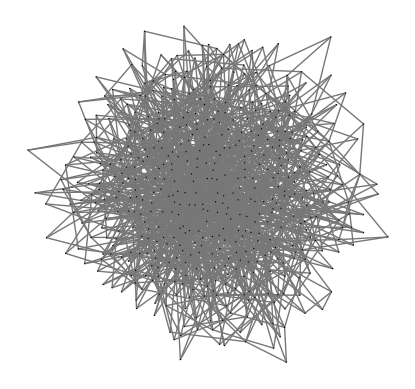

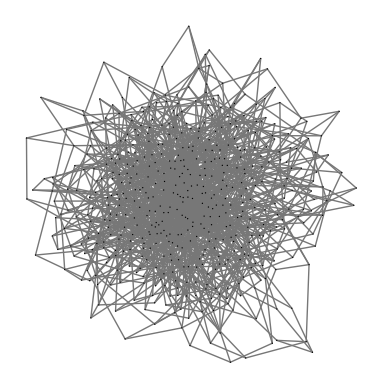

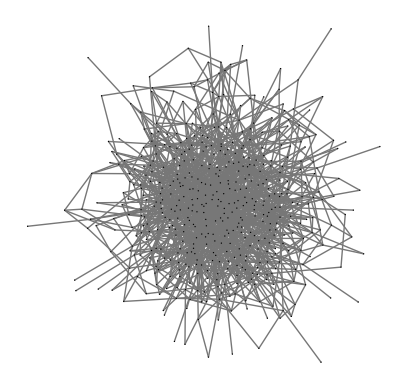

In [55]:
import random
def modularity_rewiring(g, iterations=1000, temp=0.01):
    # Get initial community structure using LPA
    communities = g.community_label_propagation()
    membership = communities.membership
    
    current_q = g.modularity(membership)
    
    for _ in range(iterations):
        # Pick two random edges (u, v) and (x, y)
        edges = random.sample(list(g.es), 2)
        u, v = edges[0].tuple
        x, y = edges[1].tuple
        
        # Ensure no self-loops or multi-edges in proposed swap (u, x) and (v, y)
        if len({u, v, x, y}) == 4 and not g.are_connected(u, x) and not g.are_connected(v, y):
            # Calculate potential modularity change efficiently
            # We accept if it increases internal community edges
            same_comm_old = (membership[u] == membership[v]) + (membership[x] == membership[y])
            same_comm_new = (membership[u] == membership[x]) + (membership[v] == membership[y])
            
            delta_q = same_comm_new - same_comm_old
            
            # Metropolis Criteria
            if delta_q > 0 or random.random() < np.exp(delta_q / temp):
                g.delete_edges(edges)
                g.add_edges([(u, x), (v, y)])
                
    return g

def triangle_closing_rewire(g, iterations=500):
    for _ in range(iterations):
        # 1. Find an open triplet: a-b-c where a and c are NOT connected
        nodes = random.sample(range(g.vcount()), 1)
        neighbors = g.neighbors(nodes[0])
        if len(neighbors) < 2: continue
        
        a, c = random.sample(neighbors, 2)
        if g.are_connected(a, c): continue
        
        # 2. Pick a random edge (u, v) from the graph to "sacrifice"
        random_edge = random.choice(g.es)
        u, v = random_edge.tuple
        
        # 3. Swap: Connect (a, c) to close triangle, use (u, v) nodes to maintain degrees
        # This is a simplified version; true degree-preservation 
        # requires a 2-edge to 2-edge swap.
        if not g.are_connected(a, c):
            g.delete_edges([random_edge])
            g.add_edge(a, c)
            # To keep degree sequence perfect, we'd need to re-link u and v elsewhere
            
    return g


# Usage: Start with BA graph, then rewire
g_ba = ig.Graph.Barabasi(n=500, m=3)
plot_graph(g_ba)
print(statistics(g_ba))

g_modular = modularity_rewiring(g_ba)
plot_graph(g_modular)
print(statistics(g_modular))

g_clustered = triangle_closing_rewire(g_ba)
g_clustered = g_clustered.subgraph(max(g_clustered.connected_components(), key=len))
plot_graph(g_clustered)
print(statistics(g_clustered))

   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      150.0     1722.0      22.96   3.0      1.891723          0.262277   

          r         Q  
0 -0.016644  0.146988  
   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      150.0     1656.0      22.08   3.0      1.899418          0.259701   

          r         Q  
0 -0.071641  0.157533  
   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      150.0     1656.0      22.08   3.0      1.914541          0.333283   

          r         Q  
0 -0.063289  0.203003  
   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      150.0     1639.0  21.853333   3.0      1.890201          0.261557   

          r         Q  
0 -0.116034  0.159486  
   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      150.0     1648.0  21.973333   3.0      1.925369           0.42206   

          r         Q  
0 -0.122258  0.2866

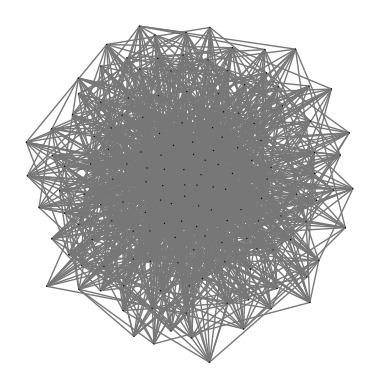

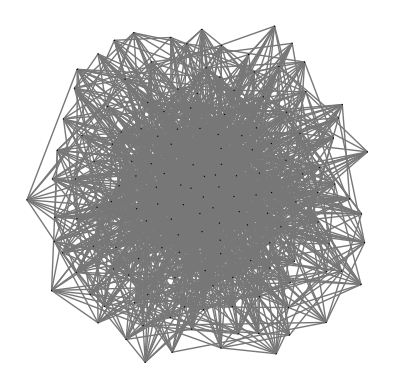

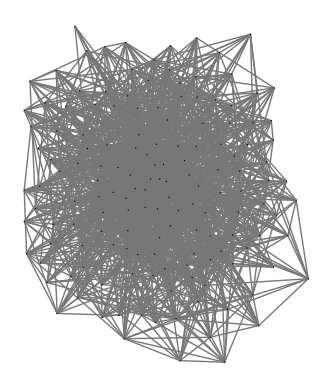

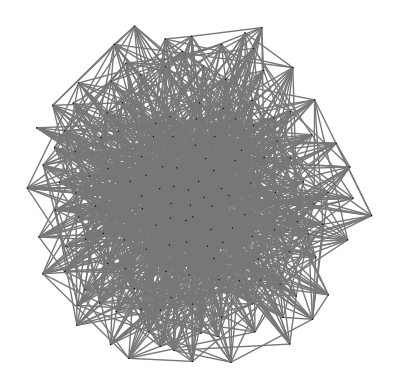

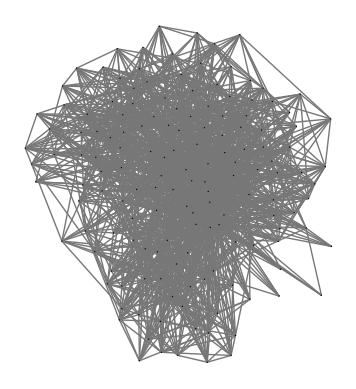

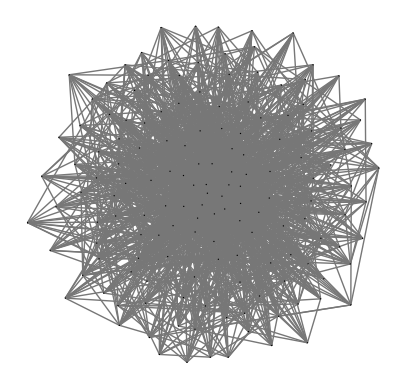

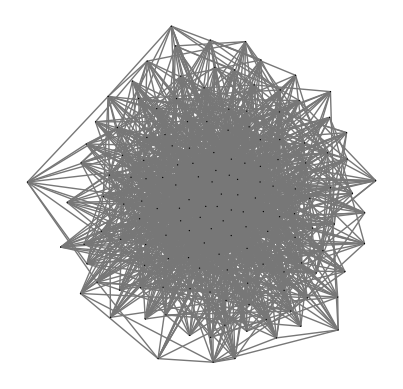

In [73]:
from utils.graph_models import statistics,LPA,holme_kim, powerlaw_cluster
from utils.plot import plot_graph

N = 150
m = 12

G_0 = ig.Graph.Barabasi(N,m, directed=False)
plot_graph(G_0)
print(statistics(G_0))

G_1 = holme_kim(N,m,p = 0.1)
plot_graph(G_1)
print(statistics(G_1))

G_2 = holme_kim(N,m,p = 0.9)
plot_graph(G_2)
print(statistics(G_2))

G_1 = powerlaw_cluster(N,m,p = 0.1)
plot_graph(G_1)
print(statistics(G_1))

G_2 = powerlaw_cluster(N,m,p = 0.9)
plot_graph(G_2)
print(statistics(G_2))

G_3 = LPA(N,m,gamma=2.5)
plot_graph(G_3)
print(statistics(G_3))

G_4 = LPA(N,m,gamma=3.5)
plot_graph(G_4)
print(statistics(G_4))


   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      150.0      150.0       3.24  13.0      5.457539          0.498382   

          r        Q  
0  0.136752  0.76207  
Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 12/12 [00:00<?, ?it/s]

--- Power-law Analysis ---
Alpha (Coefficient): 2.2702
xmin (Threshold): 2.0
Loglikelihood Ratio (R): -2.0859
p-value: 0.0370
Result: Power-law distribution is NOT statistically significant.


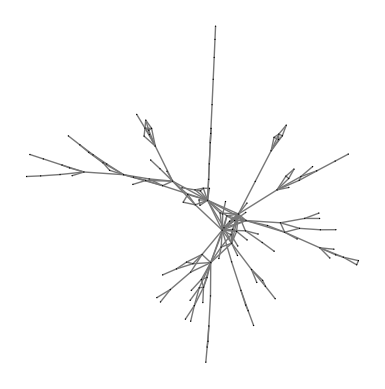

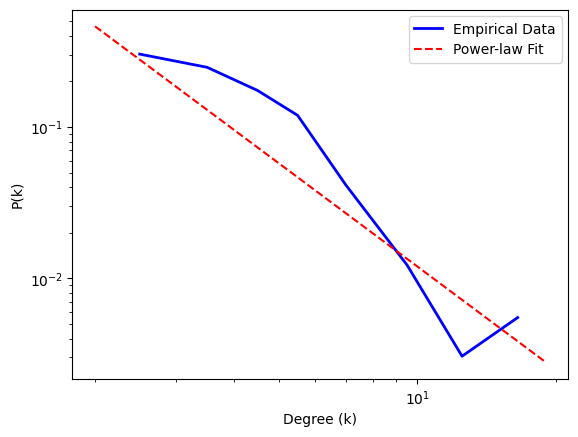

   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      147.0      147.0   3.278912   9.0      4.028329          0.066642   

          r         Q  
0  0.056587  0.552582  
   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      150.0      150.0       7.44   5.0      2.706667           0.30036   

          r         Q  
0 -0.059194  0.394354  
Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 20/20 [00:00<00:00, 1120.35it/s]

--- Power-law Analysis ---
Alpha (Coefficient): 2.5829
xmin (Threshold): 5.0
Loglikelihood Ratio (R): -0.4511
p-value: 0.6519
Result: Power-law distribution is NOT statistically significant.


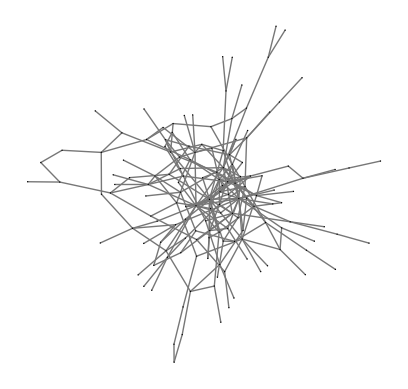

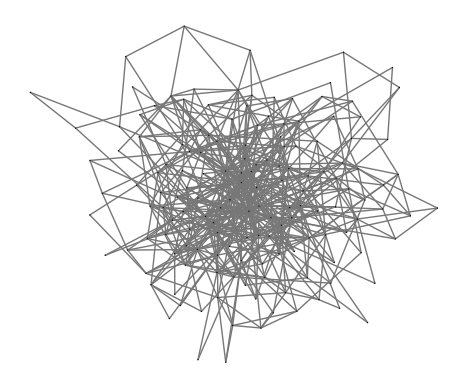

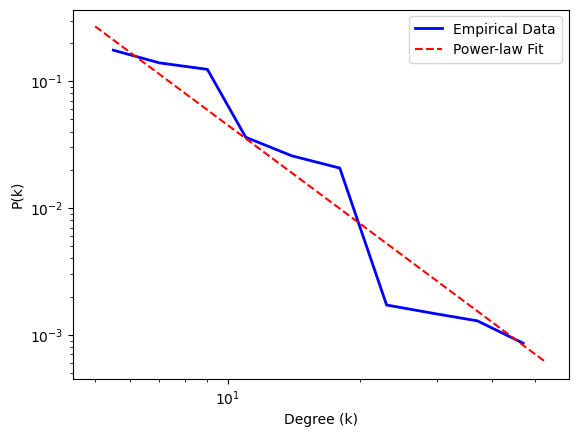

In [ ]:
from utils.graph_models import forest_fire_custom
# --- Execution ---
# N = 500
# P_FORWARD = 0.37  # Typical value for realistic networks
# R_BACK = 0.32     # Typical ratio
N = 150
P_FORWARD = 0.35  # Typical value for realistic networks
R_BACK = 0.32     # Typical ratio


ff_graph = forest_fire_custom(N, P_FORWARD, R_BACK)
print(statistics(ff_graph))
plot_graph(ff_graph)
analyze_powerlaw(ff_graph)

ff_graph.rewire(n=200, mode="simple")
ff_graph = ff_graph.subgraph(max(ff_graph.connected_components(), key=len))
print(statistics(ff_graph))
plot_graph(ff_graph)


ff_graph = forest_fire_custom(N, P_FORWARD, R_BACK, n_ambassadors=2)
print(statistics(ff_graph))
plot_graph(ff_graph)
analyze_powerlaw(ff_graph)

   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      100.0      170.0        3.4  10.0      4.420808          0.520832   

          r         Q  
0 -0.035289  0.672699  
Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 9/9 [00:00<00:00, 996.75it/s]

--- Power-law Analysis ---
Alpha (Coefficient): 2.2613
xmin (Threshold): 2.0
Loglikelihood Ratio (R): -0.8067
p-value: 0.4198
Result: Power-law distribution is NOT statistically significant.


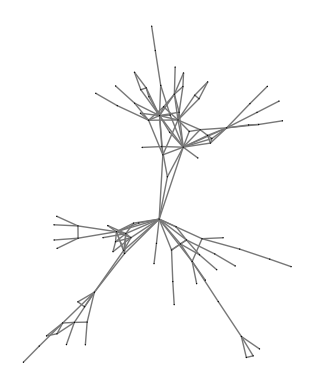

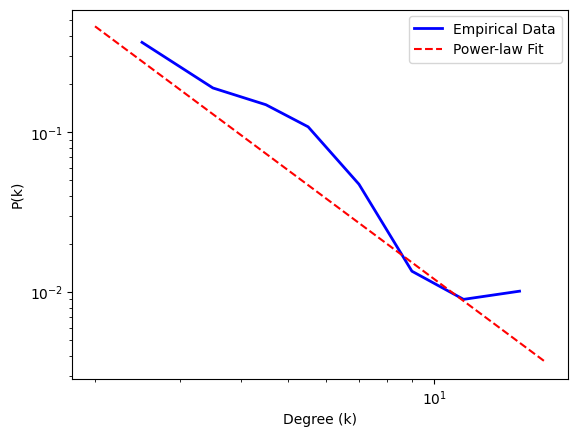

In [63]:
g_ff = ig.Graph.Forest_Fire(n=100, fw_prob=0.35, bw_factor=0.3, directed=False)
print(statistics(g_ff))
plot_graph(g_ff)
analyze_powerlaw(g_ff)

   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      200.0      538.0       5.38   8.0      3.679548          0.171446   

          r         Q  
0  0.321678  0.581503  
Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 10/10 [00:00<00:00, 914.95it/s]

--- Power-law Analysis ---
Alpha (Coefficient): 2.4223
xmin (Threshold): 3.0
Loglikelihood Ratio (R): -12.6364
p-value: 0.0000
Result: Power-law distribution is NOT statistically significant.


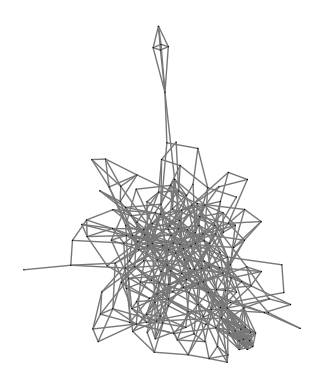

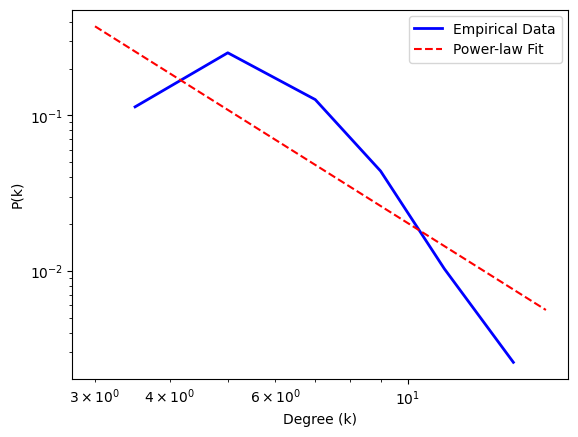

In [ ]:
import igraph as ig
import numpy as np
import math
from utils.graph_models import BTER


# Example Usage:
# Generating a Power Law degree sequence
g_bter = BTER(n=200,gamma=2.5, rho=0.5)

g_bter = g_bter.subgraph(max(g_bter.connected_components(), key=len))
print(statistics(g_bter))
plot_graph(g_bter)
analyze_powerlaw(g_bter)

   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      239.0      331.0   2.769874  17.0      6.758518          0.072743   

        r         Q  
0 -0.0324  0.733902  
Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 4/4 [00:00<?, ?it/s]

--- Power-law Analysis ---
Alpha (Coefficient): 1.7427
xmin (Threshold): 1.0
Loglikelihood Ratio (R): -16.3661
p-value: 0.0000
Result: Power-law distribution is NOT statistically significant.


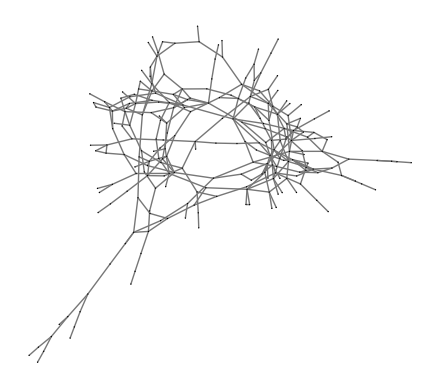

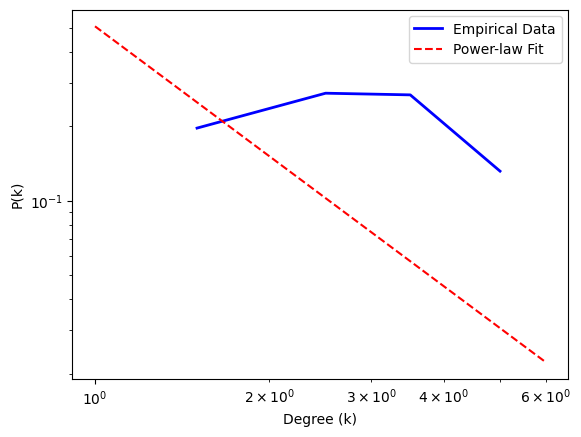

In [110]:
import random
def generate_hrg(n_levels, p_vector):
    """
    n_levels: Depth of the hierarchy (Total nodes = 2^n_levels)
    p_vector: List of probabilities for each level, from leaves to root.
              Example: [0.8, 0.4, 0.1, 0.01]
    """
    num_nodes = 2**n_levels
    g = ig.Graph(num_nodes)
    
    # Iterate through all pairs of nodes
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            # Find the level of their Lowest Common Ancestor (LCA)
            # This is a bitwise trick for binary trees
            diff = i ^ j
            lca_level = diff.bit_length() - 1 
            
            # Get probability for this level
            p = p_vector[lca_level] if lca_level < len(p_vector) else 0.001
            
            if random.random() < p:
                g.add_edge(i, j)
    return g

# --- Configuration for your specific needs ---
# To get High Modularity but Low Clustering:
# 1. High p at low n_levels (creates communities)
# 2. Very low p at the root (keeps it sparse)
# 3. Ensure the internal communities aren't "cliques" (keep p < 1.0)

n_levels = 8 # 2^7 = 128 nodes
# Probabilities from bottom (closest relatives) to top (distant)
probs = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005] 

hrg_graph = generate_hrg(n_levels, probs)
hrg_graph = hrg_graph.subgraph(max(hrg_graph.connected_components(), key=len))
print(statistics(hrg_graph))
plot_graph(hrg_graph)
analyze_powerlaw(hrg_graph)



   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      150.0      150.0   3.413333   6.0      2.963221          0.465841   

          r         Q  
0 -0.277835  0.544342  
Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 6/6 [00:00<?, ?it/s]

--- Power-law Analysis ---
Alpha (Coefficient): 1.7957
xmin (Threshold): 1.0
Loglikelihood Ratio (R): -0.0771
p-value: 0.9385
Result: Power-law distribution is NOT statistically significant.


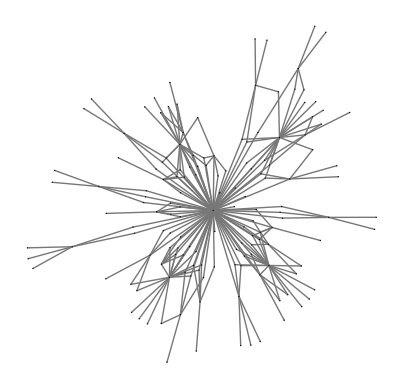

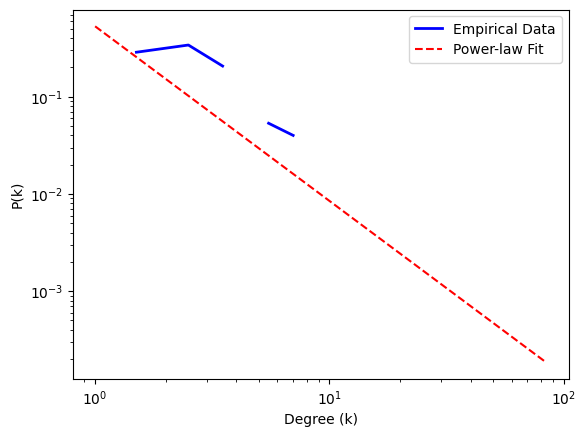

   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      150.0      150.0   3.413333   6.0      2.882148           0.43406   

          r         Q  
0 -0.267684  0.488838  


<Axes: >

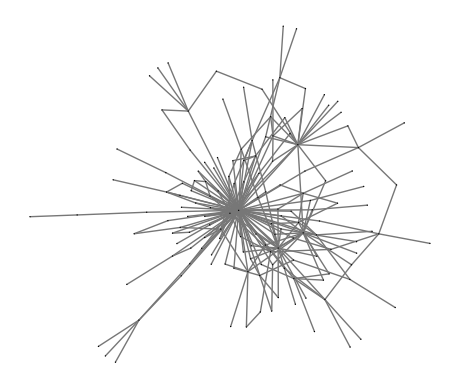

In [34]:
import numpy as np
from utils.structural_diversity_analysis import analyze_powerlaw,statistics
def hierarchical_graph(n_levels, n_base=4, q=1.0, init_block = 'star'):
    """
    n_levels: Number of replication steps (3-4 is usually enough for large N)
    n_base: Size of the initial base module (clique)
    q: Probability of connecting a peripheral node to the central hub.
       Lower q increases Modularity (Q) and changes Gamma.
    """
    # 1. Create the initial base module (Level 0)
    if init_block == 'clique':
        g = ig.Graph.Full(n_base)
    elif init_block == 'star':
        g = ig.Graph.Star(n_base, mode="undirected")
    
    central_node = 0
    
    for level in range(n_levels):
        nodes_per_replica = g.vcount()
        # We will create (n_base - 1) new copies of the existing graph
        for copy_idx in range(4):    
            # Merge the copy into the main graph
            old_vcount = g.vcount()
            g.add_vertices(nodes_per_replica)
            new_nodes = list(range(old_vcount, g.vcount()))
            
            existing_edges = [(e.source, e.target) for e in g.es if e.source < nodes_per_replica and e.target < nodes_per_replica]
            
            for src, tgt in existing_edges:
                g.add_edge(src + old_vcount, tgt + old_vcount)

            # Connect peripheral nodes of the replica to the original central hub
            # In the original model, every node connects. 
            # With 'q', we make it stochastic.
            for v_idx in new_nodes:
                if np.random.rand() < q:
                    g.add_edge(v_idx, central_node)
                    
    return g
    
import igraph as ig
import random


# # Level 3 with a base of 4 creates a graph of 4^4 = 256 nodes.
g_hier = hierarchical_graph(n_levels=2, n_base=6, q=0.5)
print(statistics(g_hier))
plot_graph(g_hier)
analyze_powerlaw(g_hier)

g_hier.rewire(n=100, mode="simple")
g_hier = g_hier.subgraph(max(g_hier.connected_components(), key=len))
print(statistics(g_hier))
plot_graph(g_hier)

# g_hier = hierarchical_graph(n_levels=3, n_base=1, q=0.9, init_block='star')
# print(statistics(g_hier))

   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      150.0      150.0   7.866667   4.0      2.524474          0.133058   

          r         Q  
0 -0.082721  0.307673  
Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 19/19 [00:00<00:00, 1134.90it/s]

--- Power-law Analysis ---
Alpha (Coefficient): 2.6613
xmin (Threshold): 5.0
Loglikelihood Ratio (R): 0.9034
p-value: 0.3663
Result: Power-law distribution is NOT statistically significant.


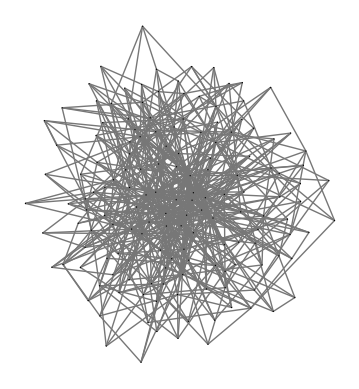

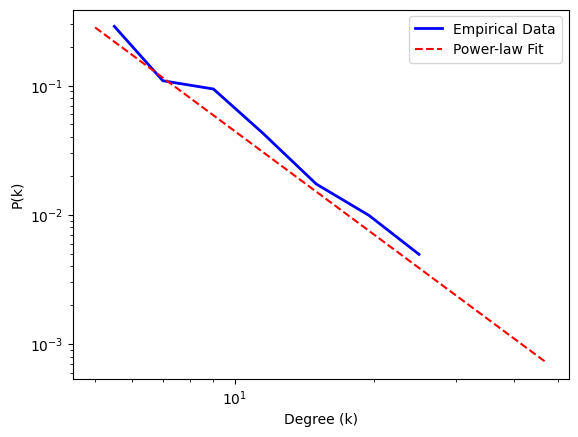

In [10]:
def link_communities(n, m):
    # 1. Generate a base graph with a "messy" real-world structure
    # Barabási-Albert is good for low clustering and power-law degrees
    g = ig.Graph.Barabasi(n=n, m=m, directed=False)
    
    # 2. Create the Line Graph 
    # Nodes in 'line_g' represent the Edges in 'g'
    line_g = g.linegraph()
    
    # 3. Detect communities on the EDGES
    # Fast-greedy is efficient for this transformation
    clusters = line_g.community_fastgreedy().as_clustering()
    
    # 4. Assign membership
    # Each edge in the original graph 'g' now has a community ID
    g.es["community"] = clusters.membership
    
    return g

g = link_communities(150, 4)
plot_graph(g)
print(statistics(g))
analyze_powerlaw(g)

#### SBM

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 18/18 [00:00<00:00, 1995.81it/s]

--- Power-law Analysis ---
Alpha (Coefficient): 2.7123
xmin (Threshold): 13.0
Loglikelihood Ratio (R): -25.6600
p-value: 0.0000
Result: Power-law distribution is NOT statistically significant.


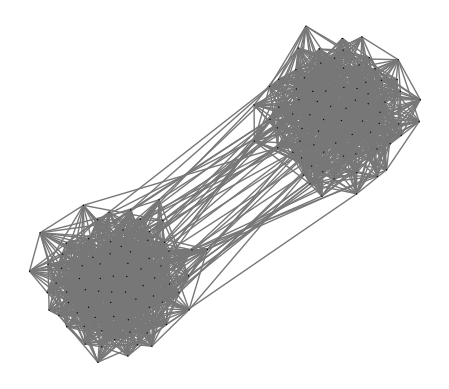

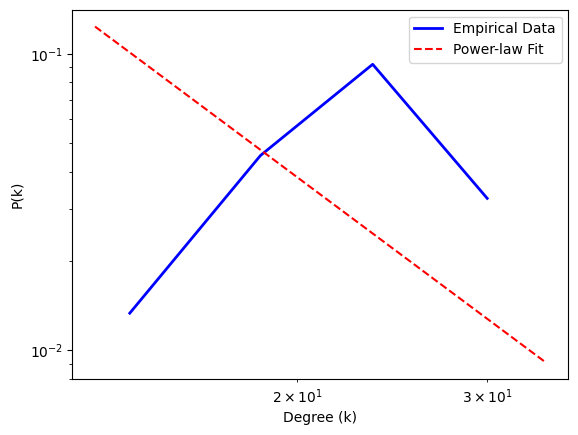

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 23/23 [00:00<00:00, 722.08it/s]

--- Power-law Analysis ---
Alpha (Coefficient): 2.5118
xmin (Threshold): 8.0
Loglikelihood Ratio (R): -12.5681
p-value: 0.0000
Result: Power-law distribution is NOT statistically significant.


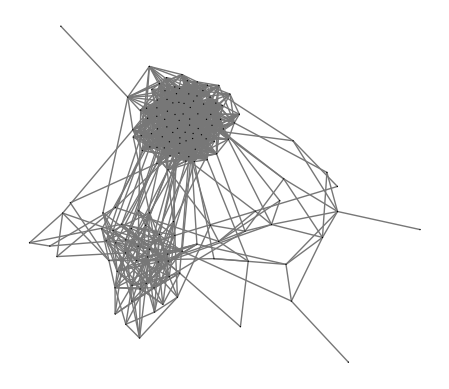

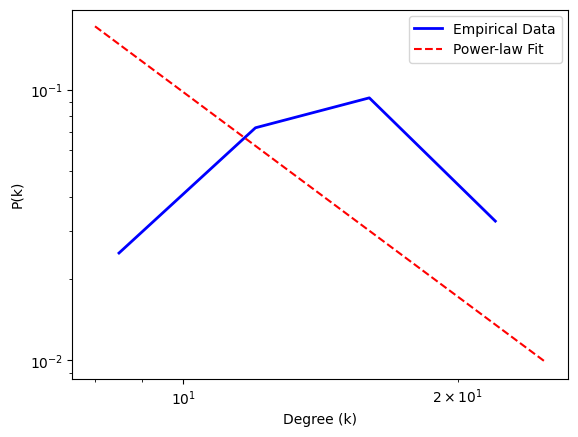

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 29/29 [00:00<00:00, 862.10it/s]

--- Power-law Analysis ---
Alpha (Coefficient): 2.6652
xmin (Threshold): 7.0
Loglikelihood Ratio (R): -0.9467
p-value: 0.3438
Result: Power-law distribution is NOT statistically significant.


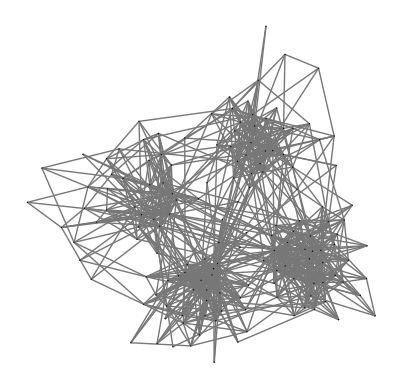

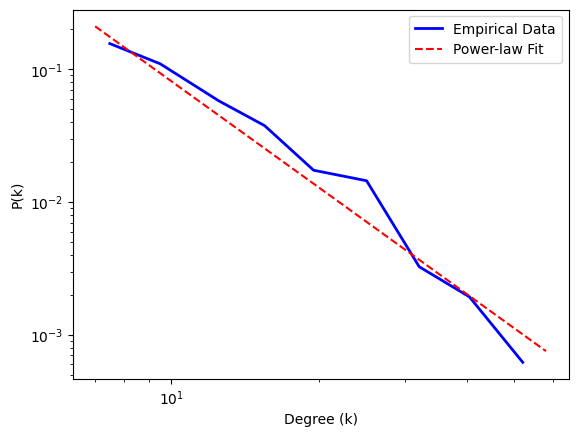

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 36/36 [00:00<00:00, 2108.90it/s]

--- Power-law Analysis ---
Alpha (Coefficient): 2.9377
xmin (Threshold): 13.0
Loglikelihood Ratio (R): 0.9473
p-value: 0.3435
Result: Power-law distribution is NOT statistically significant.


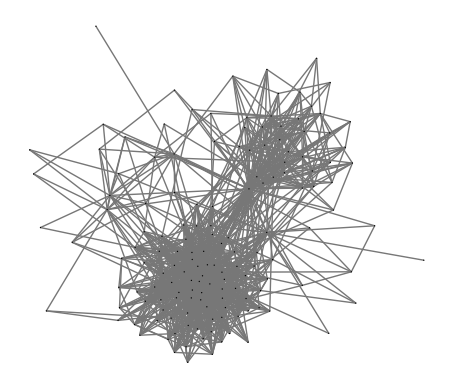

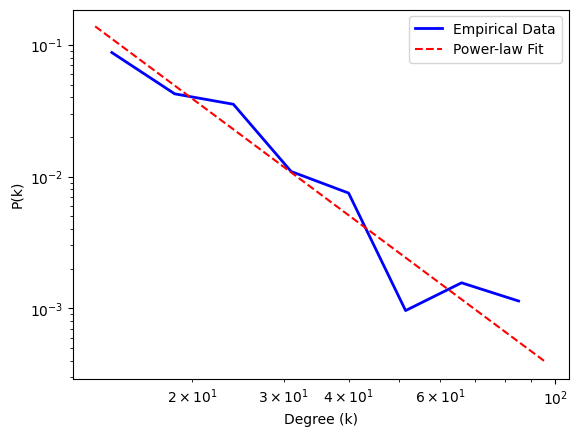

In [14]:
from utils.graph_models import SBM,DCSBM
G_1 = SBM(N=150,p_in=0.3,p_out = 0.01,num_blocks = 2)
plot_graph(G_1)
analyze_powerlaw(G_1)

G_1 = SBM(N=150,p_in=0.2,p_out = 0.01,num_blocks = 4,unbalanced=True)
plot_graph(G_1)
analyze_powerlaw(G_1)

G_1 = DCSBM(N=150,p_in=0.2,p_out = 0.01,num_blocks = 4)
plot_graph(G_1)
analyze_powerlaw(G_1)

G_1 = DCSBM(N=150,p_in=0.2,p_out = 0.01,num_blocks = 4,unbalanced=True)
plot_graph(G_1)
analyze_powerlaw(G_1)

#### 杠铃图

<Axes: >

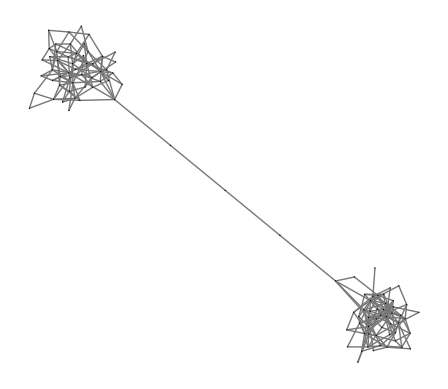

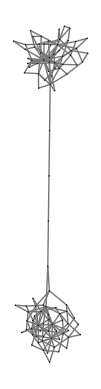

In [22]:
from utils.graph_models import barbell
G = barbell(N=100,p_in=0.1,path_len=3)
plot_graph(G)

G = barbell(N=100,p_in=0.1,path_len=3,type="BA")
plot_graph(G)

#### 星形社区图

<Axes: >

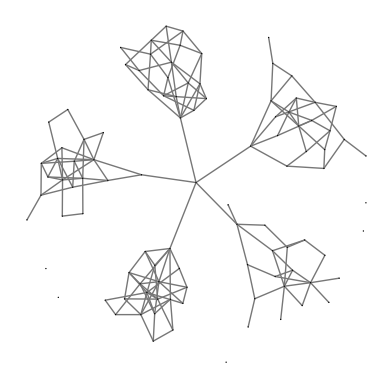

In [23]:
from utils.graph_models import star_community
G = star_community(N=100,p_in=0.2, num_communities=5)
plot_graph(G)

#### 项链图

<Axes: >

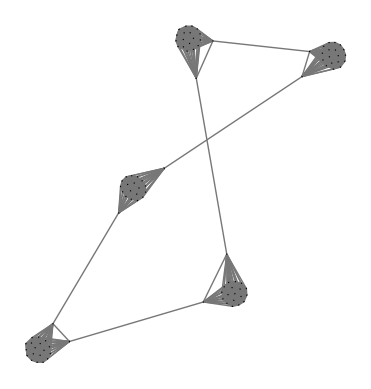

In [24]:
from utils.graph_models import necklace
G = necklace(N=100, num_cliques=5)
plot_graph(G)

## spectral analyze

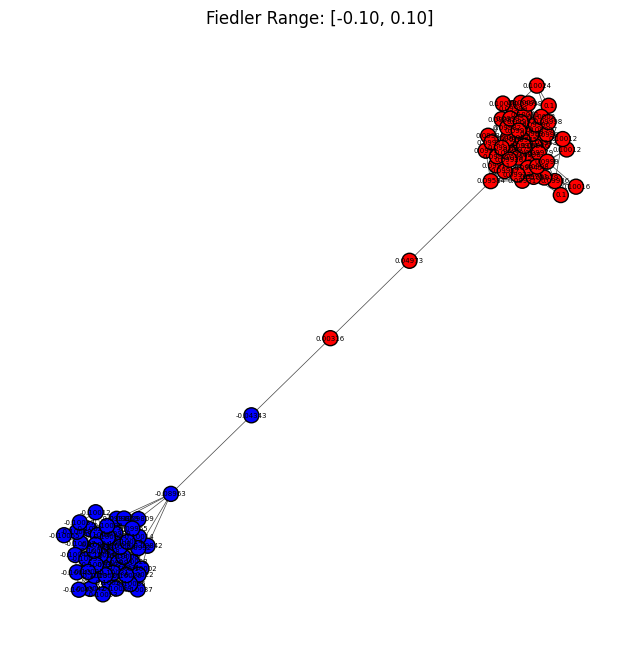

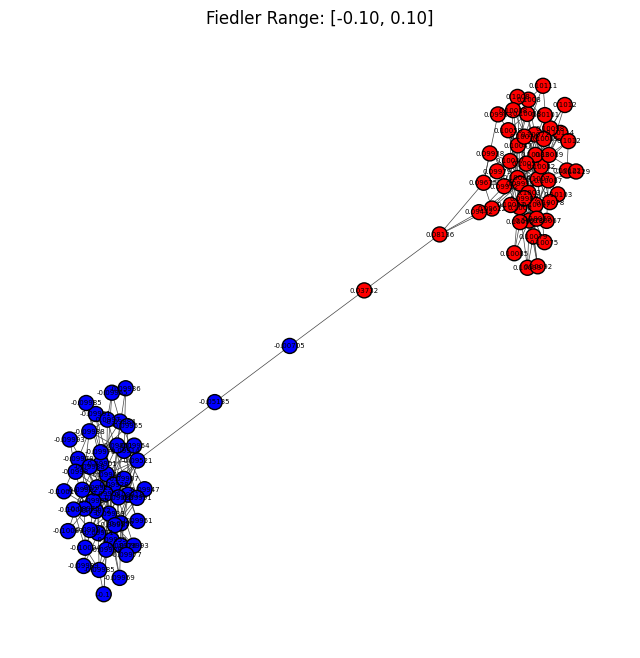

In [11]:
import igraph as ig
import numpy as np
np.set_printoptions(precision=5)
from scipy.linalg import eigh
import matplotlib.pyplot as plt

def plot_fiedler(g):
    # 1. Calculate Laplacian and Fiedler Vector
    L = np.array(g.laplacian())
    vals, vecs = eigh(L)
    fiedler_vec = np.array(vecs[:, 1]) # Second column is λ2's eigenvector
    fiedler_vec = np.around(fiedler_vec, decimals=5)

    # 2. Setup Visualization
    # Color nodes by their value in the Fiedler vector (Red to Blue)
    layout = g.layout_fruchterman_reingold()
    
    # Map Fiedler values to a color gradient
    fig, ax = plt.subplots(figsize=(8, 8))
    ig.plot(
        g, 
        target=ax,
        layout=layout,
        vertex_color=[ "red" if x > 0 else "blue" for x in fiedler_vec ],
        vertex_size=15,
        edge_width=0.5,
        vertex_label=fiedler_vec,
        vertex_label_size = 5
        
    )
    plt.title(f"Fiedler Range: [{min(fiedler_vec):.2f}, {max(fiedler_vec):.2f}]")
    plt.show()

# Generate a Scale-Free Barbell for visualization
from utils.graph_models import barbell
g = barbell(N=100,p_in=0.15,path_len=3,type="ER")
plot_fiedler(g)

g = barbell(N=100,p_in=0.15,path_len=3,type="BA")
plot_fiedler(g)

在一个社区环中，会看到一组小特征值 $(\lambda_2, \lambda_3, \dots, \lambda_k)$.

这些k特征值都非常接近零。接近零的特征值数量描述了网络中存在多少几乎断开的社区。

\lambda_1 总是为0，表示最大连通子图（如果图是连通图，那就是图本身）

\lambda_k 和 \lambda_{k+1} 会有很大差距

First 7 eigenvalues:
λ1: 0.00000
λ2: 0.05464
λ3: 0.05583
λ4: 0.13043
λ5: 0.13753
λ6: 0.16342
λ7: 1.31795


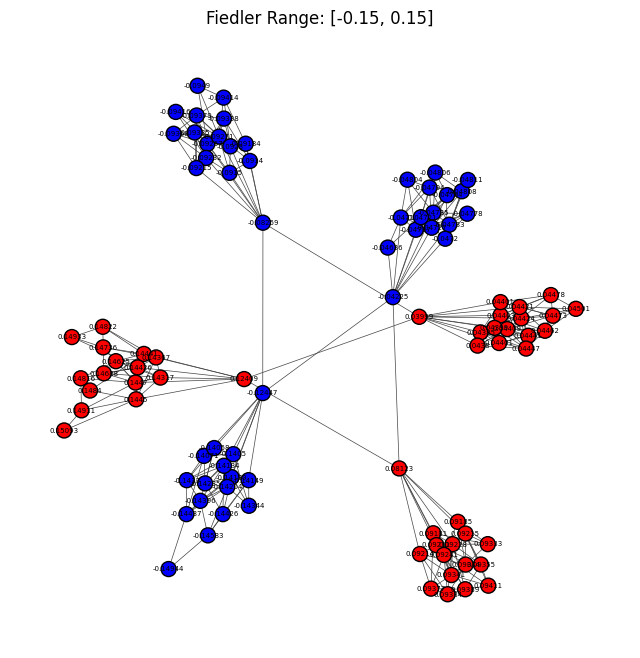

In [18]:
from utils.graph_models import ring_community
num_communities = 6
g = ring_community(N = 100,p_in=0.4, num_communities=num_communities)
# Calculate Eigenvalues
L = np.array(g.laplacian())
vals = eigh(L, eigvals_only=True)

print(f"First {num_communities+1} eigenvalues:")
for i in range(num_communities+1):
    print(f"λ{i+1}: {vals[i]:.5f}")

plot_fiedler(g)

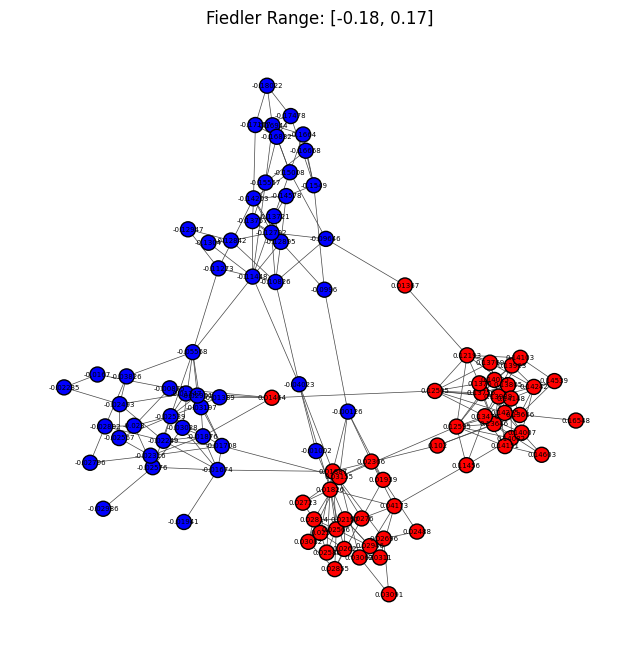

In [26]:
from utils.graph_models import SBM
g = SBM(N=100,p_in=0.2,p_out=0.003,num_blocks=4)
plot_fiedler(g)

## real dataset analyze

In [ ]:
sys.path.append(r"O:\My_Codes\GD2026\MIND-ND\utils")
from common import load_g
# # data_path = "real/FINDER/Gnutella31.pkl"
data_path = "real/social/soc-Epinions1.pkl"
g = load_g(data_path,name='test') 
statistics(g)

In [58]:
import igraph as ig
import sys
sys.path.append(r"O:\My_Codes\GD2026\MIND-ND\utils")
from common import load_g
# data_path = "real/FINDER/Crime.pkl"
data_path = "real/bio/maayan-figeys.pkl"
 
g = load_g(data_path,name='test') 
# g = ig.Graph.Barabasi(n=50, m=4, directed=False)
statistics(g)

unconnected graph
   Num_nodes  Num_edges  AvgDegree  Clustering Coffe         r         Q
0     2239.0     2239.0   5.745422          0.070995 -0.330527  0.508925


In [ ]:
import os
import pickle
import igraph as ig
graph_dir = 'graphs/train/200_300_ER_LPA_COPY_SBM_LBR'

net_dict = {}
for net_no,path in enumerate(sorted(os.listdir(graph_dir))):
    with open(os.path.join(graph_dir,path), 'rb') as f:
        g_dict = pickle.load(f)
        net_dict[net_no] = g_dict 
    # print(g)
    # ig.summary(g)
save_name = f"{os.path.basename(graph_dir)}.pkl"
with open(save_name,'wb') as f:
    pickle.dump(net_dict,f)

#### combine datasets

In [18]:
import pickle

# Load all dictionaries
dicts = []
filenames = ['switched_graphs_1218.pkl', 'switched_graphs_1218_2.pkl', '100_200_ER_LPA_COPY_10000.pkl']

for filename in filenames:
    with open(filename, 'rb') as f:
        dicts.append(pickle.load(f))

# Combine with sequential keys
combined_net_dict = {}
current_key = 0

for net_dict in dicts:
    for value in net_dict.values():
        combined_net_dict[current_key] = value
        current_key += 1

# Save combined dictionary
with open('combined_graphs.pkl', 'wb') as f:
    pickle.dump(combined_net_dict, f)

print(f"Combined {sum(len(d) for d in dicts)} graphs into {len(combined_net_dict)} entries")


Combined 6603 graphs into 6603 entries
